# Xception + CVAE + SSIM — Opción B (Colab, reestructurado)

CVAE condicional con **prior aprendido** `p(z|θ)`, usando como encoder un **backbone Xception pre-entrenado** (modelo inverso V3100) congelado salvo los últimos bloques.

```
img ──► Xception backbone (V3100, fine-tune bloques 11-14) ──► GAP ──► (B,2048)
                                                                         │
θ ──► Prior p(z|θ) ──► μ_p, logσ²_p, ce ─────────────────────────────────┤
                                                                         ▼
                                              Encoder q(z|emb,ce) ──► μ_q, logσ²_q ──► z
                                                                         │
                                              Decoder(z, ce) ──► x̂ (40×40, tanh)
```

**Loss:** `(1 − SSIM) + λ_L1·L1 + β·KLD(q‖p)` con β en rampa (épocas 1→12) y plateau.

---

### ⚠️ ANTES DE EMPEZAR — elegir GPU correcta

El error `CUDA_ERROR_INVALID_HANDLE` que aparecía no es del código: es una **incompatibilidad de TensorFlow 2.20 con las GPU L4** que asigna Colab. Las GPU **T4** y **A100** funcionan bien.

1. Menú **Runtime → Change runtime type → Hardware accelerator → T4 GPU** (o A100 si tenés Pro).
2. Ejecutar la **celda 0** (instalación) y **reiniciar el runtime**.
3. Continuar. La **celda 2 (self-test)** verifica que la GPU funcione *antes* de construir nada — si falla, te dice exactamente qué hacer.

**Datasets Kaggle:**
- `carloscanamejoy/dataset-spines-united-v2` → `dataset_unificado_v2.npz` (claves `img`, `params`, `labels`)
- `carloscanamejoy/weights-xception-model` → `modelo_xception_fulldatabaseV3100.h5`


## 0. Instalar dependencias y forzar Keras 2  *(correr una vez → REINICIAR RUNTIME)*

Keras 3 (default en Colab) tiene un bug que rompe la GPU con `Op:Cast`. Se fuerza Keras 2 con `tf-keras` + `TF_USE_LEGACY_KERAS=1` (igual que en el notebook del ViT que sí corre).


In [1]:
# Correr UNA vez y después: Runtime → Restart session
!pip install -q tf-keras kaggle

import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"
print("✅ Listo. REINICIA EL RUNTIME (Runtime → Restart session) y seguí desde la celda 1.")


✅ Listo. REINICIA EL RUNTIME (Runtime → Restart session) y seguí desde la celda 1.


## 1. Imports y configuración global

In [2]:
import os
# CRÍTICO: Keras 2 legacy ANTES de importar TF (evita el bug de Keras 3 en Colab)
os.environ["TF_USE_LEGACY_KERAS"] = "1"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import json, time, pickle, glob, zipfile, shutil
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers, Model
from tensorflow.keras.layers import (
    GlobalAveragePooling2D, Dense, Input, Dropout, BatchNormalization,
)
from tensorflow.keras.applications import Xception
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt

# ---- Semilla única para TODO el notebook ----
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ---- Memory growth ----
for gpu in tf.config.list_physical_devices("GPU"):
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except Exception as e:
        print(f"WARN memory growth: {e}")

print(f"TF: {tf.__version__}")
try:
    import tf_keras
    print(f"Keras backend: tf_keras {tf_keras.__version__}  ✅ (Keras 2 legacy)")
except Exception:
    print("⚠️  tf_keras no detectado — ¿corriste la celda 0 y reiniciaste el runtime?")
print(f"GPUs: {tf.config.list_physical_devices('GPU')}")


TF: 2.20.0
Keras backend: tf_keras 2.20.0  ✅ (Keras 2 legacy)
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Self-test de GPU  *(falla rápido y claro)*

Lanza un kernel CUDA mínimo (`random` + `matmul`). Si la GPU asignada es una L4 incompatible, esto explota acá con un mensaje accionable **en vez de** morir más adelante dentro del modelo Xception.


In [3]:
def gpu_self_test():
    gpus = tf.config.list_physical_devices("GPU")
    if not gpus:
        print("⚠️  No hay GPU. El entrenamiento irá MUY lento en CPU.")
        print("    Runtime → Change runtime type → T4 GPU")
        return False
    try:
        with tf.device("/GPU:0"):
            a = tf.random.normal([512, 512])      # stateless_uniform/Sub bajo el capó
            b = tf.random.normal([512, 512])
            c = tf.matmul(a, b)                    # MatMul en GPU
            _ = float(tf.reduce_sum(c).numpy())    # fuerza ejecución
        # nombre de la GPU
        try:
            name = tf.config.experimental.get_device_details(gpus[0]).get("device_name", "GPU")
        except Exception:
            name = "GPU"
        print(f"✅ GPU OK: {name} — kernels CUDA funcionan.")
        return True
    except Exception as e:
        print("❌ La GPU asignada NO puede lanzar kernels CUDA (típico de L4 con TF 2.20).")
        print("   SOLUCIÓN: Runtime → Change runtime type → T4 GPU → Save,")
        print("   luego Runtime → Restart session y volvé a correr desde la celda 1.")
        print(f"\n   Detalle: {type(e).__name__}: {str(e)[:200]}")
        raise SystemExit("GPU incompatible — cambiá a T4 y reiniciá (ver mensaje arriba).")

_GPU_OK = gpu_self_test()


✅ GPU OK: NVIDIA A100-SXM4-40GB — kernels CUDA funcionan.


## 3. Subir `kaggle.json` y descargar dataset + pesos

In [4]:
# --- kaggle.json ---
KAGGLE_JSON = "/root/.kaggle/kaggle.json"
if not os.path.exists(KAGGLE_JSON):
    try:
        from google.colab import files
        print("⬆️  Subí tu kaggle.json:")
        up = files.upload()
        jname = next(k for k in up if k.endswith(".json"))
        os.makedirs("/root/.kaggle", exist_ok=True)
        shutil.move(jname, KAGGLE_JSON)
    except Exception as e:
        raise RuntimeError(f"Colocá kaggle.json en {KAGGLE_JSON}: {e}")
os.chmod(KAGGLE_JSON, 0o600)
print("kaggle.json OK")

# --- descargas (--unzip extrae directo) ---
os.makedirs("/content/data",    exist_ok=True)
os.makedirs("/content/weights", exist_ok=True)
!kaggle datasets download -d carloscanamejoy/dataset-spines-united-v2 -p /content/data    --unzip
!kaggle datasets download -d carloscanamejoy/weights-xception-model   -p /content/weights --unzip


DATASET_PATH     = "/content/data/dataset_unificado_v2.npz"
XCEPTION_WEIGHTS = "/content/weights/modelo_xception_fulldatabaseV3100.h5"

for tag, p in [("Dataset", DATASET_PATH), ("Pesos Xception", XCEPTION_WEIGHTS)]:
    print(("✅" if os.path.exists(p) else "❌ NO ENCONTRADO"), tag, "→", p)
assert os.path.exists(DATASET_PATH),     "Falta el dataset"
assert os.path.exists(XCEPTION_WEIGHTS), "Falta el .h5 de pesos"

⬆️  Subí tu kaggle.json:


Saving kaggle.json to kaggle.json
kaggle.json OK
Dataset URL: https://www.kaggle.com/datasets/carloscanamejoy/dataset-spines-united-v2
License(s): unknown
100% 421M/421M [00:24<00:00, 18.0MB/s]

Dataset URL: https://www.kaggle.com/datasets/carloscanamejoy/weights-xception-model
License(s): apache-2.0
100% 769M/769M [00:46<00:00, 17.4MB/s]

✅ Dataset → /content/data/dataset_unificado_v2.npz
✅ Pesos Xception → /content/weights/modelo_xception_fulldatabaseV3100.h5


## 4. Hiperparámetros (Optuna + ajustes anti-colapso Opción B) y rutas de salida

In [5]:
# --- HPs base de Optuna + 3 ajustes anti-colapso ---
LR_BACKBONE   = 1.3540658782530271e-06
LR_CVAE       = 0.000872261525233455
BETA_MAX      = 0.18      # ajuste B (era 0.4348): no aplastar el posterior
LAMBDA_L1     = 0.05      # ajuste B (era 0.0104): penalizar colapso a imagen constante
Z_DIM         = 192
COND_EMB_DIM  = 32
BATCH_SIZE    = 64        # A100: batch grande (era 16). Warm-start tolera el cambio de varianza del gradiente.

# --- Config de entrenamiento ---
EPOCHS         = 30
BETA_START     = 1e-6
BETA_RAMP_END  = 12       # β sube linealmente ép.1→12, luego plateau en BETA_MAX
COND_DIM       = 8        # nº de parámetros físicos θ
SUBSAMPLE_FRAC = 1.0      # 100% del dataset
KL_ACTIVE_THR  = 0.01     # umbral para contar dimensiones latentes "activas"

# --- Tamaños (igual que ddpm_spines_train y la variante CVAE-ViT) ---
# Se entrena a 40×40 con la imagen real pad-reflejada 39→40 (sin interpolación);
# el crop a 39×39 es solo de evaluación/visualización. Preserva la textura fina.
NATIVE_SIZE = 39
MODEL_SIZE  = 40

def pad_reflect_39_to_40(x):
    """(B, 39, 39, 1) → (B, 40, 40, 1) con reflect en bordes inferior/derecho."""
    return tf.pad(x, [[0, 0], [0, 1], [0, 1], [0, 0]], mode="REFLECT")

# --- Warm-start: reanudar desde los pesos de la corrida anterior ---
# Misma config (HP de Optuna intactos); el reentreno solo corrige el target a
# pad-reflect 39→40 (antes era resize bilineal a 40×40), para que la textura y las
# métricas SSIM/L1 sean consistentes con el DDPM y comparables con el CVAE-ViT.
WARM_START      = True
WARMSTART_CKPT  = "/content/weights/cvae_xception_optB_best.weights.h5"

# --- Rutas de salida ---
OUTPUT_DIR = "/content/outputs"
CKPT_DIR   = os.path.join(OUTPUT_DIR, "checkpoints")
FIG_DIR    = os.path.join(OUTPUT_DIR, "figures")
for d in (OUTPUT_DIR, CKPT_DIR, FIG_DIR):
    os.makedirs(d, exist_ok=True)

# Nombres NUEVOS para no pisar los pesos viejos (el warm-start los lee como entrada).
BEST_CKPT   = os.path.join(CKPT_DIR, "cvae_xception_optB_padreflect_best.weights.h5")   # mejor val_loss
LAST_CKPT   = os.path.join(CKPT_DIR, "cvae_xception_optB_padreflect_last.weights.h5")   # última época
SCALER_PKL  = os.path.join(OUTPUT_DIR, "param_scaler_xception_optB.pkl")
HISTORY_JSON= os.path.join(OUTPUT_DIR, "history_xception_optB_padreflect.json")

print(f"z_dim={Z_DIM} cond_emb={COND_EMB_DIM} batch={BATCH_SIZE} "
      f"β_max={BETA_MAX} λL1={LAMBDA_L1}")
print(f"epochs={EPOCHS}  β-ramp ép.1→{BETA_RAMP_END}  subsample={SUBSAMPLE_FRAC*100:.0f}%")
print(f"target: pad-reflect {NATIVE_SIZE}→{MODEL_SIZE} | warm_start={WARM_START}")
print(f"outputs → {OUTPUT_DIR}")

z_dim=192 cond_emb=32 batch=64 β_max=0.18 λL1=0.05
epochs=30  β-ramp ép.1→12  subsample=100%
target: pad-reflect 39→40 | warm_start=True
outputs → /content/outputs


## 5. Carga de datos, subsample y splits estratificados

**Reproducibilidad:** todo deriva de `SEED=42`.

**Protocolo de split** (alineado con el notebook del ViT):
1. Subsample del **10%** del dataset completo — estratificado por `labels` si existen (mantiene la proporción de estructuras magnéticas), si no, aleatorio.
2. Sobre ese 10%: split **70 / 15 / 15** (train / val / test), estratificado por label.
3. `MinMaxScaler` ajustado **sólo con train** y aplicado a val/test (sin fuga de información).


In [6]:
data = np.load(DATASET_PATH)
print("npz keys:", data.files)

imgs   = data["img"].astype(np.float32)
params = data["params"].astype(np.float32)
labels = data["labels"].astype(int) if "labels" in data.files else None
if imgs.ndim == 3:
    imgs = imgs[..., np.newaxis]

N = len(imgs)
print(f"Total: {N:,} imgs {imgs.shape[1:]}  range [{imgs.min():.2f}, {imgs.max():.2f}]"
      f"  | params dim={params.shape[1]}"
      f"  | labels={'sí' if labels is not None else 'no'}")

# 1) subsample (estratificado por label si hay). Si frac>=1.0 usamos TODO el dataset.
if SUBSAMPLE_FRAC >= 1.0:
    sub_idx = np.arange(N)
    print("Usando el 100% del dataset (sin subsample)")
else:
    n_sub = int(N * SUBSAMPLE_FRAC)
    sub_idx, _ = train_test_split(
        np.arange(N), train_size=n_sub, random_state=SEED,
        stratify=(labels if labels is not None else None))

imgs_sub       = imgs[sub_idx]
params_sub_raw = params[sub_idx]
labels_sub     = labels[sub_idx] if labels is not None else None

# 2) split 70/15/15 sobre el subsample (índices LOCALES al subsample)
loc = np.arange(len(sub_idx))
idx_train, idx_temp = train_test_split(
    loc, test_size=0.30, random_state=SEED, stratify=labels_sub)
strat_temp = labels_sub[idx_temp] if labels_sub is not None else None
idx_val, idx_test = train_test_split(
    idx_temp, test_size=0.50, random_state=SEED, stratify=strat_temp)

# 3) scaler SOLO con train
scaler = MinMaxScaler().fit(params_sub_raw[idx_train])
params_train = scaler.transform(params_sub_raw[idx_train]).astype(np.float32)
params_val   = scaler.transform(params_sub_raw[idx_val]  ).astype(np.float32)
params_test  = scaler.transform(params_sub_raw[idx_test] ).astype(np.float32)

# guardar scaler ya mismo (no depende del entrenamiento)
with open(SCALER_PKL, "wb") as f:
    pickle.dump(scaler, f)

print(f"\nSubsample: {len(sub_idx):,} ({SUBSAMPLE_FRAC*100:.0f}%)")
print(f"  train={len(idx_train):,}  val={len(idx_val):,}  test={len(idx_test):,}")
print(f"  scaler guardado → {SCALER_PKL}")


npz keys: ['img', 'params', 'labels', 'label_keys', 'label_names', 'column_names']
Total: 169,671 imgs (39, 39, 1)  range [-1.00, 1.00]  | params dim=8  | labels=sí
Usando el 100% del dataset (sin subsample)

Subsample: 169,671 (100%)
  train=118,769  val=25,451  test=25,451
  scaler guardado → /content/outputs/param_scaler_xception_optB.pkl


## 6. `tf.data` pipelines (en CPU)

El pipeline se construye dentro de `tf.device("/CPU:0")`: las operaciones de `shuffle`/`from_tensor_slices` deben vivir en CPU (en GPU disparan `Op:Equal` → `CUDA_ERROR_INVALID_HANDLE`). El `prefetch` mueve los batches a GPU a tiempo, sin costo de rendimiento. La GPU se reserva para el modelo.


In [7]:
def preprocess(img, param):
    img_xc     = tf.image.resize(img, (224, 224))     # Xception input (224×224 obligatorio)
    img_xc     = tf.image.grayscale_to_rgb(img_xc)    # 1→3 canales
    img_target = pad_reflect_39_to_40(img)            # target 40×40 (pad reflect, sin interpolación)
    return img_xc, param, img_target

with tf.device("/CPU:0"):
    x_train = np.ascontiguousarray(imgs_sub[idx_train])
    x_val   = np.ascontiguousarray(imgs_sub[idx_val])

    train_ds = (
        tf.data.Dataset.from_tensor_slices((x_train, params_train))
        .shuffle(10000, seed=SEED, reshuffle_each_iteration=True)
        .batch(BATCH_SIZE)
        .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
        .prefetch(tf.data.AUTOTUNE)
    )
    val_ds = (
        tf.data.Dataset.from_tensor_slices((x_val, params_val))
        .batch(BATCH_SIZE)
        .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
        .prefetch(tf.data.AUTOTUNE)
    )

for img_xc, param, img_target in train_ds.take(1):
    print(f"img_xc:     {img_xc.shape}  [{img_xc.numpy().min():.2f}, {img_xc.numpy().max():.2f}]")
    print(f"param:      {param.shape}")
    print(f"img_target: {img_target.shape} [{img_target.numpy().min():.2f}, {img_target.numpy().max():.2f}]")

img_xc:     (64, 224, 224, 3)  [-1.00, 1.00]
param:      (64, 8)
img_target: (64, 40, 40, 1) [-1.00, 1.00]


## 7. Backbone: cargar Xception pre-entrenado (V3100)

El `.h5` de V3100 se guardó con esta cabeza de regresión:

```
Xception(include_top=False) → GAP → BN → Dropout(0.4)
    → Dense(256, relu, l2=1e-4) → BN → Dropout(0.3) → Dense(8, linear)
```

Para que `load_weights` case **nombre-a-nombre**, reconstruimos ese modelo plano en el mismo orden, cargamos los pesos, y después recortamos el backbone tomando el tensor de **entrada al GAP** (salida del Xception, `(B,7,7,2048)`).

Se usa `weights=None` (no descargamos ImageNet; los reemplazan los de V3100). Fine-tune sólo de los **bloques 11–14**; el resto congelado.


In [8]:
\
# 1) modelo plano V3100 (mismo orden de capas que el entrenamiento original)
_inp = Input(shape=(224, 224, 3), name="input_layer")
_xc  = Xception(weights=None, include_top=False, input_tensor=_inp, pooling=None)
_x = _xc.output
_x = GlobalAveragePooling2D()(_x)
_x = BatchNormalization()(_x)
_x = Dropout(0.4)(_x)
_x = Dense(256, activation="relu", kernel_regularizer=regularizers.l2(1e-4))(_x)
_x = BatchNormalization()(_x)
_x = Dropout(0.3)(_x)
_x = Dense(8, activation="linear")(_x)
_temp = Model(_inp, _x, name="functional")

# 2) cargar pesos V3100
_temp.load_weights(XCEPTION_WEIGHTS)
print(f"✅ Pesos V3100 cargados: {XCEPTION_WEIGHTS}")

# 3) recortar backbone: input → entrada del GAP (salida del Xception)
gap_layer = next(l for l in _temp.layers if isinstance(l, GlobalAveragePooling2D))
backbone = Model(_temp.input, gap_layer.input, name="xception_backbone")
print(f"Backbone: {backbone.input_shape} → {backbone.output_shape}")
del _temp

# 4) fine-tune sólo bloques 11-14
TRAINABLE_BLOCKS = {11, 12, 13, 14}
def _is_trainable(name):
    if not name.startswith("block"):
        return False
    num = ""
    for ch in name[5:]:
        if ch.isdigit(): num += ch
        else: break
    return bool(num) and int(num) in TRAINABLE_BLOCKS

n_tr = 0
for l in backbone.layers:
    l.trainable = _is_trainable(l.name)
    n_tr += int(l.trainable)
print(f"Backbone: {n_tr}/{len(backbone.layers)} capas entrenables "
      f"({len(backbone.trainable_variables)} vars) | bloques 11-14")


✅ Pesos V3100 cargados: /content/weights/modelo_xception_fulldatabaseV3100.h5
Backbone: (None, 224, 224, 3) → (None, 7, 7, 2048)
Backbone: 31/132 capas entrenables (40 vars) | bloques 11-14


## 8. Definición del CVAE (encoder, prior aprendido, decoder)

In [9]:
class Sampling(layers.Layer):
    def call(self, inputs):
        mu, lv = inputs
        eps = tf.random.normal(tf.shape(mu))
        return mu + eps * tf.exp(0.5 * lv)


class Encoder(layers.Layer):
    def __init__(self, z_dim, cond_emb_dim, **kw):
        super().__init__(**kw)
        self.fc1 = Dense(512, activation="silu")
        self.fc2 = Dense(256, activation="silu")
        self.fc_mu = Dense(z_dim)
        self.fc_lv = Dense(z_dim)
        self.sampling = Sampling()
    def call(self, emb, ce):
        h = tf.concat([emb, ce], axis=-1)
        h = self.fc2(self.fc1(h))
        mu, lv = self.fc_mu(h), self.fc_lv(h)
        return mu, lv, self.sampling([mu, lv])


class Prior(layers.Layer):
    """Prior aprendido p(z|θ)."""
    def __init__(self, z_dim, cond_emb_dim, **kw):
        super().__init__(**kw)
        self.cond_net = keras.Sequential([
            Dense(64,  activation="silu"),
            Dense(128, activation="silu"),
            Dense(cond_emb_dim, activation="silu"),
        ])
        self.fc_mu = Dense(z_dim)
        self.fc_lv = Dense(z_dim)
    def call(self, y):
        ce = self.cond_net(y)
        return self.fc_mu(ce), self.fc_lv(ce), ce


class Decoder(layers.Layer):
    """Decoder que emite 40×40 (sin crop interno). El crop a 39 es solo de evaluación."""
    def __init__(self, cond_emb_dim, **kw):
        super().__init__(**kw)
        self.fc_in   = Dense(512 * 5 * 5, activation="silu")
        self.reshape = layers.Reshape((5, 5, 512))
        self.up1 = layers.Conv2DTranspose(256, 4, strides=2, padding="same"); self.bn1 = layers.BatchNormalization()
        self.up2 = layers.Conv2DTranspose(128, 4, strides=2, padding="same"); self.bn2 = layers.BatchNormalization()
        self.up3 = layers.Conv2DTranspose(64,  4, strides=2, padding="same"); self.bn3 = layers.BatchNormalization()
        self.res1_c1 = layers.Conv2D(64, 3, padding="same"); self.res1_c2 = layers.Conv2D(64, 3, padding="same")
        self.res2_c1 = layers.Conv2D(64, 3, padding="same"); self.res2_c2 = layers.Conv2D(64, 3, padding="same")
        self.out_conv = layers.Conv2D(1, 1, activation="tanh")
    def call(self, z, ce, training=None):
        x = self.reshape(self.fc_in(tf.concat([z, ce], axis=-1)))
        x = tf.nn.silu(self.bn1(self.up1(x), training=training))
        x = tf.nn.silu(self.bn2(self.up2(x), training=training))
        x = tf.nn.silu(self.bn3(self.up3(x), training=training))
        h = tf.nn.silu(self.res1_c1(x)); x = tf.nn.silu(x + self.res1_c2(h))
        h = tf.nn.silu(self.res2_c1(x)); x = tf.nn.silu(x + self.res2_c2(h))
        return self.out_conv(x)                                              # (B, 40, 40, 1)


class CVAE_Xception(Model):
    def __init__(self, backbone, z_dim, cond_dim, cond_emb_dim, **kw):
        super().__init__(**kw)
        self.backbone = backbone
        self.gap      = GlobalAveragePooling2D()
        self.encoder  = Encoder(z_dim, cond_emb_dim)
        self.prior    = Prior(z_dim, cond_emb_dim)
        self.decoder  = Decoder(cond_emb_dim)
    def call(self, inputs, training=None):
        img_xc, y = inputs
        emb = self.gap(self.backbone(img_xc, training=training))
        mu_p, lv_p, ce = self.prior(y)
        mu_q, lv_q, z  = self.encoder(emb, ce)
        x_hat = self.decoder(z, ce, training=training)
        return x_hat, mu_q, lv_q, mu_p, lv_p
    def generate(self, y):
        """Generación desde el prior: z = μ_p (determinista). Devuelve 40×40."""
        mu_p, lv_p, ce = self.prior(y)
        return self.decoder(mu_p, ce, training=False)


model = CVAE_Xception(backbone, Z_DIM, COND_DIM, COND_EMB_DIM)
_ = model([tf.zeros((1, 224, 224, 3)), tf.zeros((1, COND_DIM))], training=False)  # build

print(f"Total params:    {model.count_params():,}")
print(f"Backbone params: {backbone.count_params():,}")
print(f"CVAE params:     {model.count_params() - backbone.count_params():,}")

Total params:    27,965,193
Backbone params: 20,861,480
CVAE params:     7,103,713


In [10]:
# --- Warm-start: cargar los pesos de la corrida anterior como inicialización ---
# El modelo es idéntico al previo (el decoder ya emitía 40×40), así que TODAS las
# capas se transfieren 1:1. Partimos de un modelo ya bueno y solo lo readaptamos al
# nuevo target: imagen real pad-reflejada 39→40 (antes era resize bilineal a 40).
if WARM_START:
    assert os.path.exists(WARMSTART_CKPT), f"No encuentro los pesos previos: {WARMSTART_CKPT}"
    model.load_weights(WARMSTART_CKPT)
    print(f"✅ Warm-start desde: {WARMSTART_CKPT}")
    # Sanity: una pasada para comprobar que la salida es 40×40.
    _probe, *_ = model([tf.zeros((1, 224, 224, 3)), tf.zeros((1, COND_DIM))], training=False)
    print(f"   salida del decoder: {tuple(_probe.shape)}  (debe ser (1, 40, 40, 1))")
    assert _probe.shape[1:3] == (MODEL_SIZE, MODEL_SIZE), "El decoder no emite 40×40."
else:
    print("⏭️  Sin warm-start: entrenamiento desde cero.")

✅ Warm-start desde: /content/weights/cvae_xception_optB_best.weights.h5
   salida del decoder: (1, 40, 40, 1)  (debe ser (1, 40, 40, 1))


## 9. Loss y pasos de entrenamiento / validación

**Reconstrucción:** `recon = (1 − SSIM) + λ_L1 · L1` (imágenes en `[-1,1]`, SSIM sobre `[0,1]`).
**KLD** entre posterior `q(z|·)` y prior aprendido `p(z|θ)` (forma analítica gaussiana).
**Optimización separada:** Adam distinto para backbone (LR muy bajo) y para el resto del CVAE; clip de gradiente a norma 1.

**Métricas de validación que se registran por época:**
- `val_recon` — recon con z del posterior.
- `val_gen` — recon con z = μ_p (generación desde el prior) → **métrica de selección del best**.
- `val_kld` — divergencia KL.
- `kl_active` — fracción de dims latentes activas (KLD > umbral).
- `var_q` — varianza media del posterior.
- `mu_gap` — distancia ‖μ_q − μ_p‖ (acoplamiento posterior-prior).


In [11]:
opt_backbone = keras.optimizers.Adam(learning_rate=LR_BACKBONE)
opt_cvae     = keras.optimizers.Adam(learning_rate=LR_CVAE)

backbone_vars = model.backbone.trainable_variables
cvae_vars = (model.encoder.trainable_variables + model.prior.trainable_variables +
             model.decoder.trainable_variables + model.gap.trainable_variables)
print(f"backbone vars: {len(backbone_vars)} | cvae vars: {len(cvae_vars)}")


def ssim_loss(y_true, y_pred):
    a = (y_true + 1.0) / 2.0
    b = (y_pred + 1.0) / 2.0
    return 1.0 - tf.image.ssim(a, b, max_val=1.0)


def kl_per_dim_fn(mu_q, lv_q, mu_p, lv_p):
    vq, vp = tf.exp(lv_q), tf.exp(lv_p)
    return 0.5 * (lv_p - lv_q + (vq + tf.square(mu_q - mu_p)) / vp - 1.0)


@tf.function
def train_step(img_xc, y, img_target, beta):
    # img_target ya viene pad-reflejado a 40×40; la salida del decoder es 40×40.
    with tf.GradientTape() as tape:
        x_hat, mu_q, lv_q, mu_p, lv_p = model([img_xc, y], training=True)
        ssim_val = tf.reduce_mean(ssim_loss(img_target, x_hat))
        l1_val   = tf.reduce_mean(tf.abs(x_hat - img_target))
        recon    = ssim_val + LAMBDA_L1 * l1_val
        kld  = tf.reduce_mean(kl_per_dim_fn(mu_q, lv_q, mu_p, lv_p))
        loss = recon + beta * kld

    grads = tape.gradient(loss, backbone_vars + cvae_vars)
    gb, gc = grads[:len(backbone_vars)], grads[len(backbone_vars):]
    gb = [tf.clip_by_norm(g, 1.0) if g is not None else g for g in gb]
    gc = [tf.clip_by_norm(g, 1.0) if g is not None else g for g in gc]
    opt_backbone.apply_gradients([(g, v) for g, v in zip(gb, backbone_vars) if g is not None])
    opt_cvae.apply_gradients(    [(g, v) for g, v in zip(gc, cvae_vars)     if g is not None])
    return loss, recon, kld


@tf.function
def val_step(img_xc, y, img_target, beta):
    x_hat, mu_q, lv_q, mu_p, lv_p = model([img_xc, y], training=False)
    recon = tf.reduce_mean(ssim_loss(img_target, x_hat)) + LAMBDA_L1 * tf.reduce_mean(tf.abs(x_hat - img_target))

    kpd = kl_per_dim_fn(mu_q, lv_q, mu_p, lv_p)
    kld = tf.reduce_mean(kpd)

    # val_loss total: misma forma que la loss de train (criterio de selección del best).
    loss = recon + beta * kld

    x_gen = model.generate(y)
    gen   = tf.reduce_mean(ssim_loss(img_target, x_gen)) + LAMBDA_L1 * tf.reduce_mean(tf.abs(x_gen - img_target))

    kl_mean = tf.reduce_mean(kpd, axis=0)
    active  = tf.reduce_mean(tf.cast(kl_mean > KL_ACTIVE_THR, tf.float32))
    var_q   = tf.reduce_mean(tf.exp(lv_q))
    gap     = tf.reduce_mean(tf.sqrt(tf.reduce_sum(tf.square(mu_q - mu_p), axis=1)))
    return loss, recon, kld, gen, active, var_q, gap

backbone vars: 40 | cvae vars: 42


## 10. Training loop

β: rampa lineal `BETA_START → BETA_MAX` (épocas 1→`BETA_RAMP_END`), después plateau.
Se guarda el **best** por menor `val_gen` y al final el **last**.


In [12]:
hist = {k: [] for k in
        ["train_loss", "train_recon", "train_kld",
         "val_loss", "val_recon", "val_kld", "val_gen", "kl_active", "var_q", "mu_gap", "beta"]}
best_loss = float("inf")

print("="*72)
print(f"Xception+CVAE OptB (target pad-reflect 39→40) | warm_start={WARM_START}")
print(f"β {BETA_START}→{BETA_MAX} (ramp 1-{BETA_RAMP_END}) | {EPOCHS} ep | "
      f"batch {BATCH_SIZE} | {len(idx_train):,} train imgs")
print(f"LR_backbone={LR_BACKBONE:.2e}  LR_cvae={LR_CVAE:.2e}  λL1={LAMBDA_L1}")
print("Selección del best por val_loss (recon + β·KLD), igual que el CVAE-ViT.")
print("="*72)

t_glob = time.time()
for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    if epoch <= BETA_RAMP_END:
        p = (epoch - 1) / max(1, BETA_RAMP_END - 1)
        beta = BETA_START + (BETA_MAX - BETA_START) * p
    else:
        beta = BETA_MAX
    beta_t = tf.constant(beta, tf.float32)

    # --- train ---
    tl = tr = tk = 0.0; nb = 0
    for img_xc, prm, tgt in train_ds:
        loss, rec, kld = train_step(img_xc, prm, tgt, beta_t)
        tl += float(loss); tr += float(rec); tk += float(kld); nb += 1
    tl/=nb; tr/=nb; tk/=nb

    # --- val ---
    vL = vr = vk = vg = va = vv = vgap = 0.0; nv = 0
    for img_xc, prm, tgt in val_ds:
        L, r, k, g, a, v, gap = val_step(img_xc, prm, tgt, beta_t)
        vL+=float(L); vr+=float(r); vk+=float(k); vg+=float(g); va+=float(a); vv+=float(v); vgap+=float(gap); nv+=1
    vL/=nv; vr/=nv; vk/=nv; vg/=nv; va/=nv; vv/=nv; vgap/=nv

    for kk, vv2 in zip(hist.keys(), [tl, tr, tk, vL, vr, vk, vg, va, vv, vgap, beta]):
        hist[kk].append(vv2)

    tag = ""
    if vL < best_loss:
        best_loss = vL
        model.save_weights(BEST_CKPT)
        tag += " *best"
    if va < 0.15:
        tag += " COLLAPSE"

    print(f"Ep[{epoch:3d}/{EPOCHS}] β={beta:.4f} | rec={tr:.4f} kld={tk:.4f} | "
          f"VL={vL:.4f} Vr={vr:.4f} Vk={vk:.4f} Vg={vg:.4f} | act={va:.2f} gap={vgap:.1f} vQ={vv:.3f} | "
          f"{time.time()-t0:.0f}s{tag}")

model.save_weights(LAST_CKPT)
with open(HISTORY_JSON, "w") as f:
    json.dump(hist, f, indent=2)

print(f"\nDone {(time.time()-t_glob)/60:.1f} min | best val_loss={best_loss:.4f}")
print(f"best → {BEST_CKPT}\nlast → {LAST_CKPT}\nhist → {HISTORY_JSON}")

Xception+CVAE OptB (target pad-reflect 39→40) | warm_start=True
β 1e-06→0.18 (ramp 1-12) | 30 ep | batch 64 | 118,769 train imgs
LR_backbone=1.35e-06  LR_cvae=8.72e-04  λL1=0.05
Selección del best por val_loss (recon + β·KLD), igual que el CVAE-ViT.


Ep[  1/30] β=0.0000 | rec=0.3506 kld=0.4526 | VL=0.3593 Vr=0.3593 Vk=0.7583 Vg=0.8514 | act=1.00 gap=20.9 vQ=0.073 | 166s *best
Ep[  2/30] β=0.0164 | rec=0.3554 kld=0.1552 | VL=0.3649 Vr=0.3626 Vk=0.1442 Vg=0.8483 | act=0.94 gap=19.6 vQ=0.241 | 134s
Ep[  3/30] β=0.0327 | rec=0.3673 kld=0.1198 | VL=0.4189 Vr=0.4151 Vk=0.1178 Vg=0.8634 | act=0.68 gap=18.8 vQ=0.292 | 135s
Ep[  4/30] β=0.0491 | rec=0.3734 kld=0.1057 | VL=0.4072 Vr=0.4020 Vk=0.1061 Vg=0.8502 | act=0.38 gap=18.8 vQ=0.315 | 134s
Ep[  5/30] β=0.0655 | rec=0.3701 kld=0.0968 | VL=0.3648 Vr=0.3584 Vk=0.0971 Vg=0.8452 | act=0.24 gap=18.5 vQ=0.325 | 134s
Ep[  6/30] β=0.0818 | rec=0.3636 kld=0.0906 | VL=0.4320 Vr=0.4247 Vk=0.0896 Vg=0.8540 | act=0.27 gap=18.1 vQ=0.344 | 134s
Ep[  7/30] β=0.0982 | rec=0.3672 kld=0.0853 | VL=0.3696 Vr=0.3612 Vk=0.0853 Vg=0.8463 | act=0.18 gap=18.2 vQ=0.354 | 134s
Ep[  8/30] β=0.1145 | rec=0.3703 kld=0.0814 | VL=0.5051 Vr=0.4958 Vk=0.0808 Vg=0.8621 | act=0.18 gap=17.8 vQ=0.356 | 134s
Ep[  9/30] β=0.130


Done 67.7 min | best val_loss=0.3593
best → /content/outputs/checkpoints/cvae_xception_optB_padreflect_best.weights.h5
last → /content/outputs/checkpoints/cvae_xception_optB_padreflect_last.weights.h5
hist → /content/outputs/history_xception_optB_padreflect.json


## 11. Curvas de entrenamiento

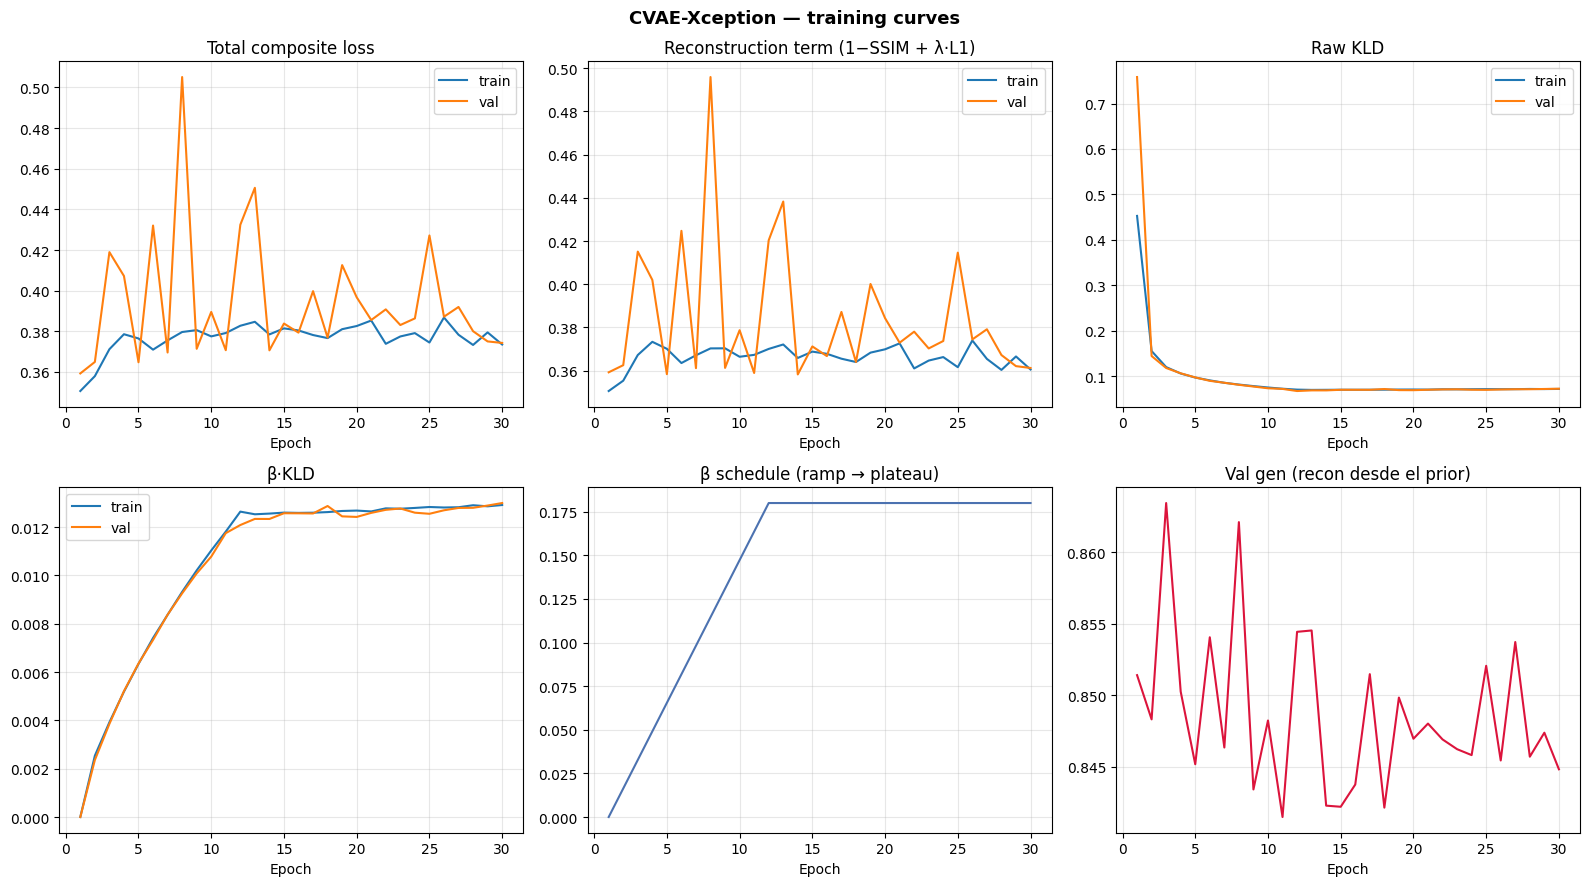

In [13]:
ep = np.arange(1, len(hist["train_loss"]) + 1)
beta_kld_tr  = [b * k for b, k in zip(hist["beta"], hist["train_kld"])]
beta_kld_val = [b * k for b, k in zip(hist["beta"], hist["val_kld"])]

# Curvas estándar (mismo layout 2×3 que el CVAE-ViT para comparación directa).
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("CVAE-Xception — training curves", fontsize=13, fontweight="bold")

axes[0,0].plot(ep, hist["train_loss"], label="train")
axes[0,0].plot(ep, hist["val_loss"],   label="val")
axes[0,0].set_title("Total composite loss"); axes[0,0].legend()

axes[0,1].plot(ep, hist["train_recon"], label="train")
axes[0,1].plot(ep, hist["val_recon"],   label="val")
axes[0,1].set_title("Reconstruction term (1−SSIM + λ·L1)"); axes[0,1].legend()

axes[0,2].plot(ep, hist["train_kld"], label="train")
axes[0,2].plot(ep, hist["val_kld"],   label="val")
axes[0,2].set_title("Raw KLD"); axes[0,2].legend()

axes[1,0].plot(ep, beta_kld_tr,  label="train")
axes[1,0].plot(ep, beta_kld_val, label="val")
axes[1,0].set_title("β·KLD"); axes[1,0].legend()

axes[1,1].plot(ep, hist["beta"], color="#4C72B0")
axes[1,1].set_title("β schedule (ramp → plateau)")

axes[1,2].plot(ep, hist["val_gen"], color="crimson")
axes[1,2].set_title("Val gen (recon desde el prior)")

for a in axes.flat:
    a.set_xlabel("Epoch"); a.grid(alpha=.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "training_curves.png"), dpi=100)
plt.show()

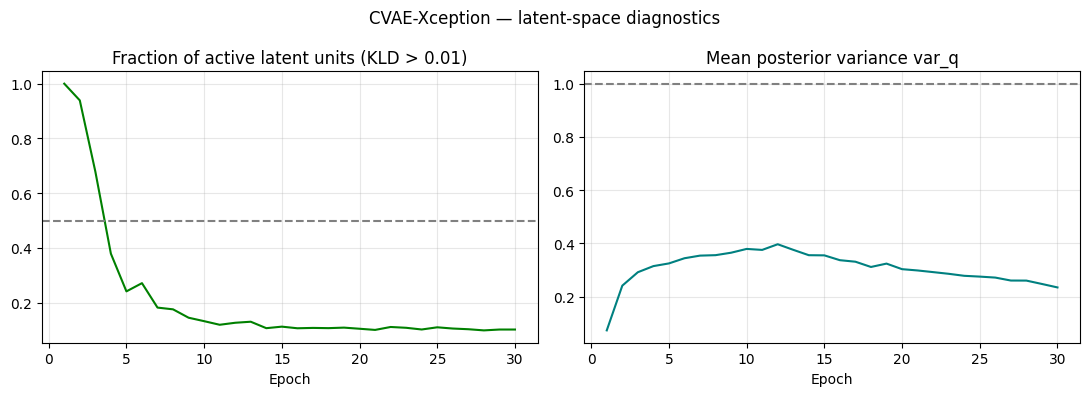

In [14]:
# Diagnósticos del espacio latente (mismo panel que el CVAE-ViT).
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(ep, hist["kl_active"], color="green")
axes[0].axhline(.5, color="gray", ls="--")
axes[0].set_title("Fraction of active latent units (KLD > 0.01)")
axes[0].set_xlabel("Epoch"); axes[0].grid(alpha=.3)
axes[1].plot(ep, hist["var_q"], color="teal")
axes[1].axhline(1.0, color="gray", ls="--")
axes[1].set_title("Mean posterior variance var_q")
axes[1].set_xlabel("Epoch"); axes[1].grid(alpha=.3)
fig.suptitle("CVAE-Xception — latent-space diagnostics")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "latent_diagnostics.png"), dpi=100)
plt.show()

## 12. Reconstrucciones y generación (carga el best)

Cargado best: /content/outputs/checkpoints/cvae_xception_optB_padreflect_best.weights.h5


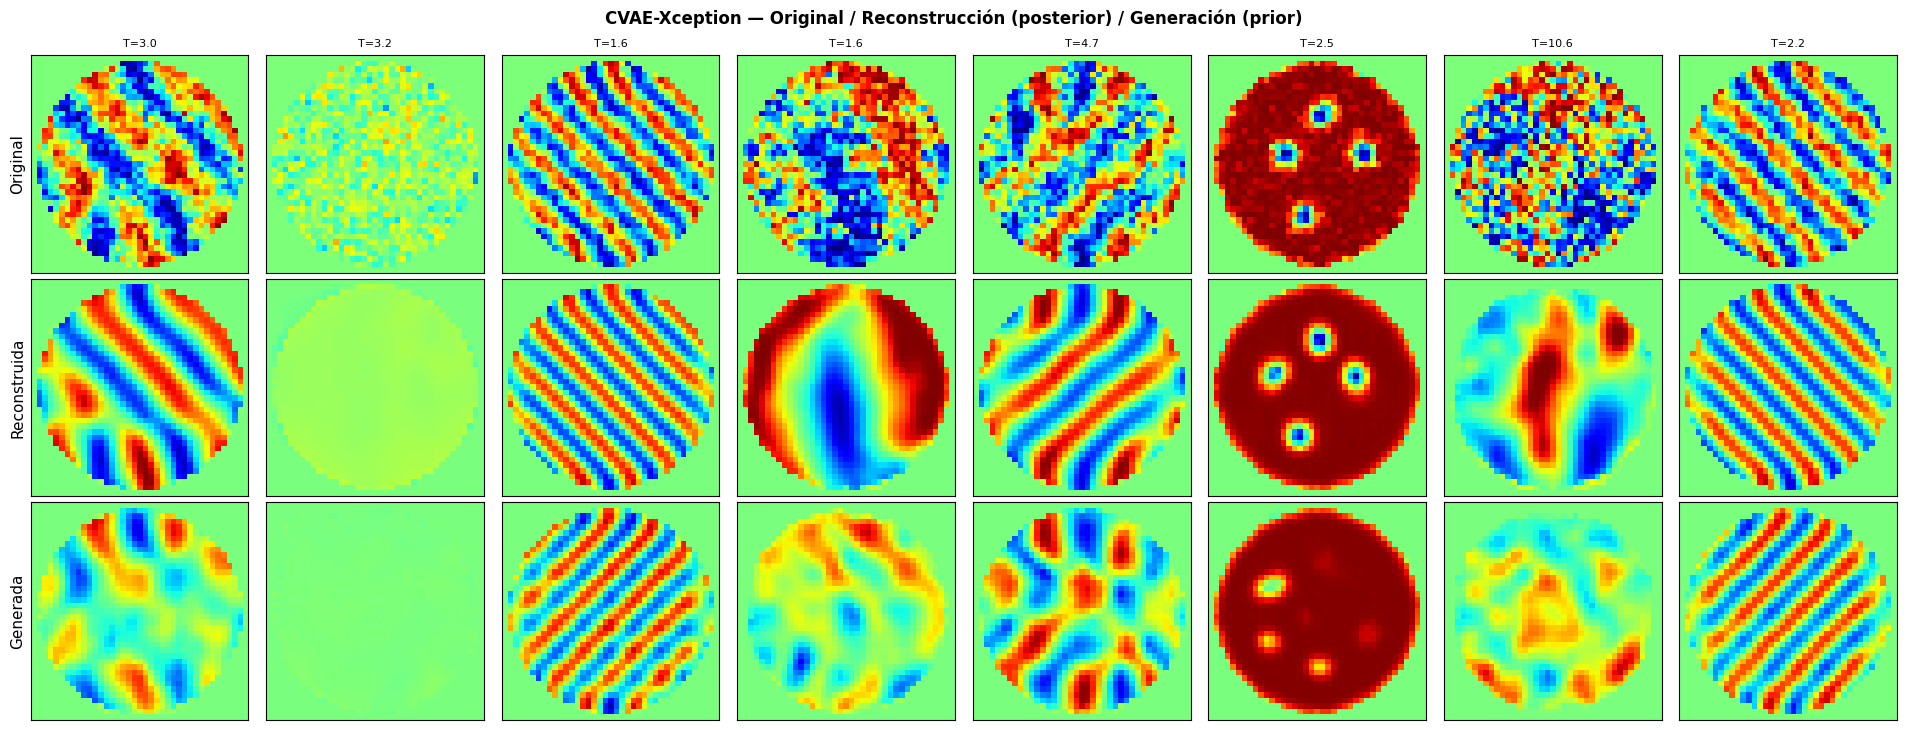

In [15]:
model.load_weights(BEST_CKPT)
print(f"Cargado best: {BEST_CKPT}")

# Panel de 3 filas: Original (39×39) / Reconstruida (posterior) / Generada (prior).
# Las salidas del decoder son 40×40 → se cropean a 39×39 ([:39,:39]) para comparar.
n_show = 8
rng_show = np.random.RandomState(SEED)
show_idx = rng_show.choice(len(idx_val), n_show, replace=False)

fig, axes = plt.subplots(3, n_show, figsize=(2.4 * n_show, 7.4))
row_labels = ["Original", "Reconstruida", "Generada"]
for col, si in enumerate(show_idx):
    real    = idx_val[si]
    img_39  = imgs_sub[real, :, :, 0]                                # 39×39 nativo
    y_in    = params_val[si:si+1]
    img_xc  = tf.image.grayscale_to_rgb(tf.image.resize(imgs_sub[real:real+1], (224, 224)))
    x_hat, *_ = model([img_xc, y_in], training=False)               # 40×40
    x_gen     = model.generate(y_in)                                # 40×40
    recon_39  = x_hat.numpy()[0, :NATIVE_SIZE, :NATIVE_SIZE, 0]
    gen_39    = x_gen.numpy()[0, :NATIVE_SIZE, :NATIVE_SIZE, 0]
    panels = [img_39, recon_39, gen_39]
    for row, im in enumerate(panels):
        a = axes[row, col]
        a.imshow(im, cmap="jet", vmin=-1, vmax=1, interpolation="nearest")
        if col == 0: a.set_ylabel(row_labels[row], fontsize=11)
        if row == 0: a.set_title(f"T={params_sub_raw[real][0]:.1f}", fontsize=8)
        a.set_xticks([]); a.set_yticks([])
fig.suptitle("CVAE-Xception — Original / Reconstrucción (posterior) / Generación (prior)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "orig_recon_gen.png"), dpi=100)
plt.show()

## 13. Resumen y archivos generados

In [16]:
gr = hist["val_gen"][-1] / (hist["val_recon"][-1] + 1e-8)
print("="*60)
print("RESUMEN — Xception + CVAE + SSIM (Opción B, pad-reflect 39→40)")
print("="*60)
print(f"  Val loss  (last): {hist['val_loss'][-1]:.4f}")
print(f"  Val loss  (best): {min(hist['val_loss']):.4f}   ← criterio de selección")
print(f"  Val recon (last): {hist['val_recon'][-1]:.4f}")
print(f"  Val gen   (last): {hist['val_gen'][-1]:.4f}")
print(f"  Gap ratio:        {gr:.2f}x")
print(f"  Active dims:      {hist['kl_active'][-1]:.2f}")
print(f"  Var q:            {hist['var_q'][-1]:.3f}")
print("="*60)
print("\nArchivos en /content/outputs:")
for root, _, fnames in os.walk(OUTPUT_DIR):
    for fn in sorted(fnames):
        p = os.path.join(root, fn)
        print(f"  {p}  ({os.path.getsize(p)/1e3:.0f} KB)")

RESUMEN — Xception + CVAE + SSIM (Opción B, pad-reflect 39→40)
  Val loss  (last): 0.3743
  Val loss  (best): 0.3593   ← criterio de selección
  Val recon (last): 0.3613
  Val gen   (last): 0.8448
  Gap ratio:        2.34x
  Active dims:      0.10
  Var q:            0.235

Archivos en /content/outputs:
  /content/outputs/history_xception_optB_padreflect.json  (8 KB)
  /content/outputs/param_scaler_xception_optB.pkl  (1 KB)
  /content/outputs/checkpoints/cvae_xception_optB_padreflect_best.weights.h5  (112271 KB)
  /content/outputs/checkpoints/cvae_xception_optB_padreflect_last.weights.h5  (112271 KB)
  /content/outputs/figures/latent_diagnostics.png  (41 KB)
  /content/outputs/figures/orig_recon_gen.png  (126 KB)
  /content/outputs/figures/training_curves.png  (174 KB)


## 14. (Opcional) Copiar resultados a Google Drive

In [17]:
# from google.colab import drive
# drive.mount("/content/drive")
# DST = "/content/drive/MyDrive/DoctoradoPaper1/cvae_xception_optB"
# os.makedirs(DST, exist_ok=True)
# for root, _, fnames in os.walk(OUTPUT_DIR):
#     for fn in fnames:
#         shutil.copy(os.path.join(root, fn), os.path.join(DST, fn))
# print("Copiado a", DST)
